# Titanic Survival Prediction – Machine Learning Modeling

## Phase 1: Problem Understanding & Planning 

### Business Problem

The Titanic disaster is one of the most well-known maritime tragedies in history. The objective of this project is to build a machine learning model that predicts whether a passenger survived the disaster based on passenger information such as age, gender, ticket class, fare, family size and embarkation details.

Predicting survival is useful because it helps demonstrate how data-driven decision-making and predictive analytics can identify patterns from historical events. This project also provides practical exposure to solving real-world classification problems using machine learning techniques.

### Problem Framing

This is a supervised machine learning classification problem.

Problem Type: Binary Classification
Target Variable:
  - 0 : Did Not Survive
  - 1 : Survived

The model will learn patterns from historical passenger records in the training dataset and use those patterns to predict survival outcomes for unseen passengers in the test dataset.


### Assumptions

The following assumptions are considered during the project:

- Passenger details such as age, gender and ticket class influence survival chances.
- Missing values can be reasonably handled through imputation or feature engineering.
- Historical patterns from the Titanic dataset are sufficient for training predictive models.
- Engineered features such as family size and passenger titles may improve model performance.


### Initial Hypotheses

Before performing exploratory data analysis, the following hypotheses are considered:

1. Female passengers had a higher survival rate than male passengers.
2. First-class passengers had a higher chance of survival.
3. Children may have received higher rescue priority.
4. Passengers travelling alone may have had different survival outcomes compared to families.
5. Higher ticket fares may be associated with better survival chances.
6. Cabin availability may indicate higher socioeconomic status and influence survival probability.


### Project Workflow

The project will follow the complete machine learning pipeline:

1. Data Loading and Understanding
2. Exploratory Data Analysis (EDA)
3. Data Cleaning and Missing Value Treatment
4. Feature Engineering
5. Encoding and Feature Scaling
6. Model Training and Evaluation
7. Final Prediction Generation
8. Submission File Preparation
9. Visualization and Reporting

## Phase 2 – Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset structure, identify missing values, discover patterns, detect anomalies and analyze relationships between variables and passenger survival outcomes.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.metrics import (accuracy_score,precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 2.1 Loading Datasets

In [2]:
# Load the datasets
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
gender_submission = pd.read_csv("../data/gender_submission.csv")

# Display shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", gender_submission.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Sample submission shape: (418, 2)


In [3]:
# Display column names
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
# Preview first 5 rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### 2.2 Initial Data Understanding

In [8]:
# Dataset information
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
# Summary statistics for numerical columns
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# Summary statistics for categorical columns
train.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


#### Initial Observations

- The training dataset contains 891 passenger records and 12 features.
- The dataset contains both numerical and categorical features.
- Some columns contain missing values such as:
  - Age
  - Cabin
  - Embarked
- The target column is 'Survived'.
- Features like Name, Ticket and Cabin may require feature engineering or transformation.

### 2.3 Missing Value Analysis

In [11]:
# Missing values count
missing_values = train.isnull().sum()

# Missing percentage
missing_percentage = (missing_values / len(train)) * 100

# Combine into dataframe
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# Sort descending
missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


#### Visualize Missing Values

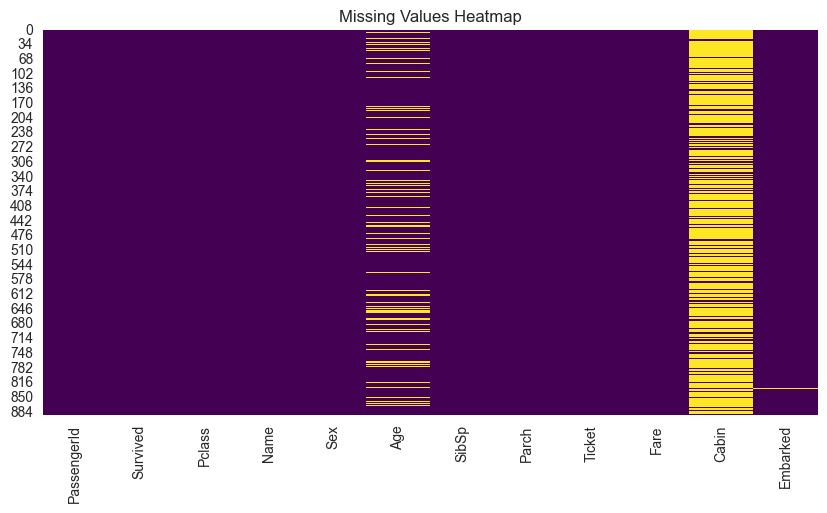

In [12]:
plt.figure(figsize=(10,5))

sns.heatmap(train.isnull(), cbar=False, cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

#### Missing Value Insights

- Cabin contains a very high percentage of missing values.
- Age has moderate missing values and will require imputation.
- Embarked has only a few missing values and can be filled using the mode.



### 2.4 Target Variable Analysis

The target variable 'Survived' indicates whether a passenger survived the Titanic disaster.

- 0 : Did Not Survive
- 1 : Survived


In [13]:
# Survival distribution
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
# Survival Percentage
survival_rate = train['Survived'].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


#### Visualization

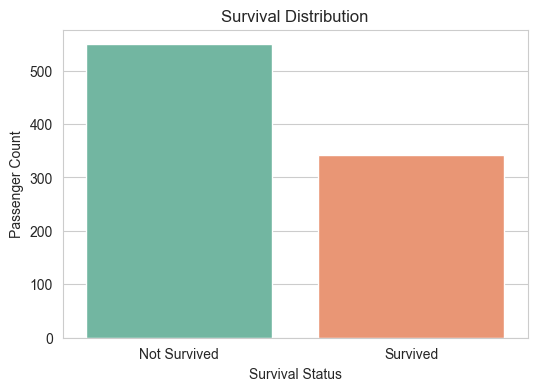

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Survived', palette='Set2')

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")

plt.xticks([0,1], ['Not Survived', 'Survived'])

plt.show()

#### Survival Distribution Insight

- The dataset is slightly imbalanced, with more passengers not survived than survived.
- Approximately 38% of passengers survived the disaster.
- This indicates that predicting survival is a meaningful classification problem.

### 2.5 Univariate Analysis

Univariate analysis focuses on understanding the distribution and characteristics of individual variables independently.

#### 2.5.1 Numerical Feature Analysis

#### Age Distribution

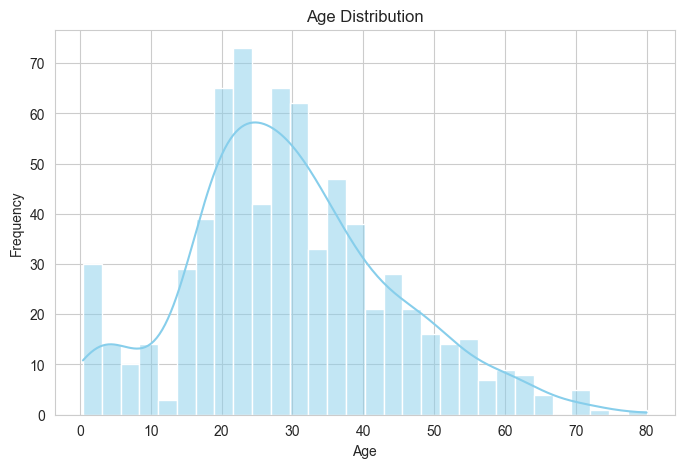

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(train['Age'], kde=True, bins=30, color='skyblue')

plt.title("Age Distribution")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

#### Age Distribution Insights

- Most passengers were between 20 and 40 years old.
- The age distribution is slightly right-skewed.
- Some missing values are present in the 'Age' column.
- Children and elderly passengers represent a smaller portion of the dataset.

#### Fare Distribution

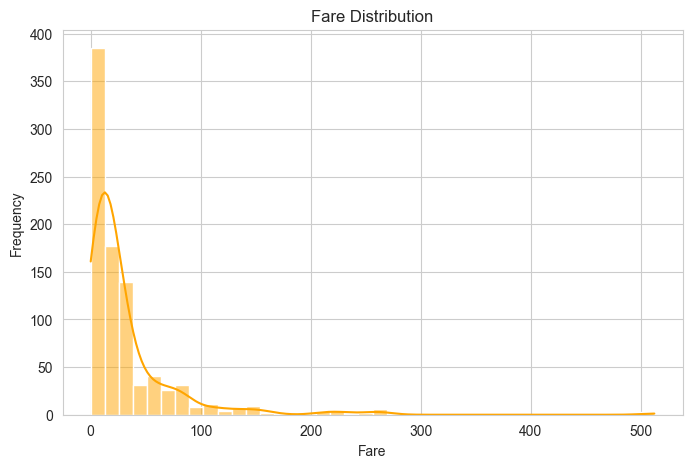

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(train['Fare'], kde=True, bins=40, color='orange')

plt.title("Fare Distribution")

plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

#### Fare Distribution Insights

- The fare distribution is highly right-skewed.
- Most passengers paid lower fares, while a small number paid significantly higher fares.
- Outliers are present in the 'Fare' column.

#### Boxplot for Fare

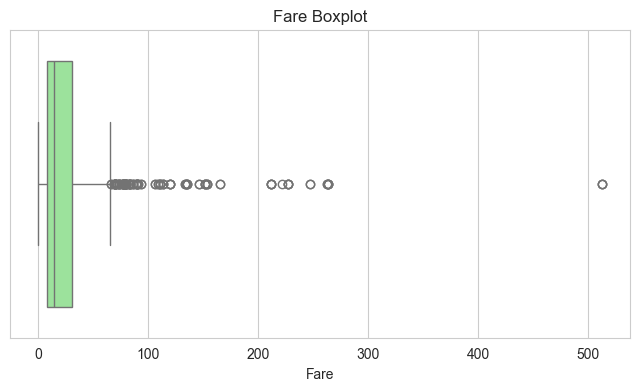

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(x=train['Fare'], color='lightgreen')

plt.title("Fare Boxplot")

plt.show()

#### 2.5.2 Categorical Feature Analysis

#### Gender Distribution

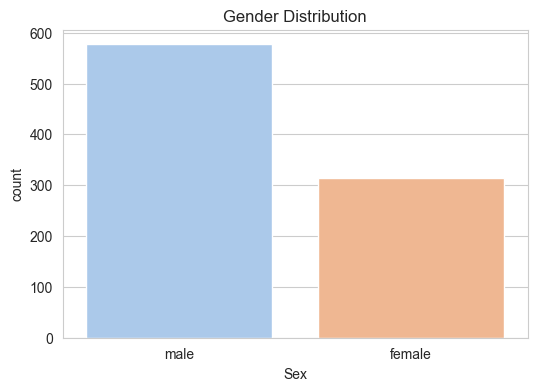

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Sex', palette='pastel')

plt.title("Gender Distribution")

plt.show()

#### Passenger Class Distribution

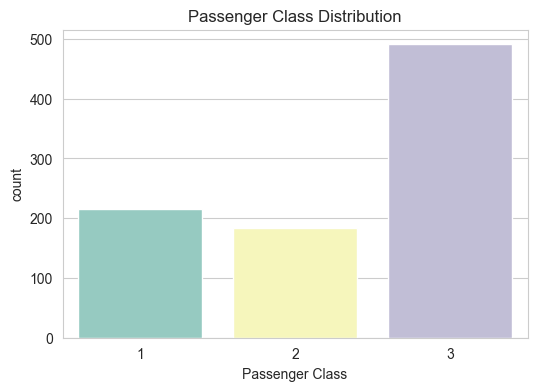

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Pclass', palette='Set3')

plt.title("Passenger Class Distribution")

plt.xlabel("Passenger Class")

plt.show()

#### Embarkation Port Distribution

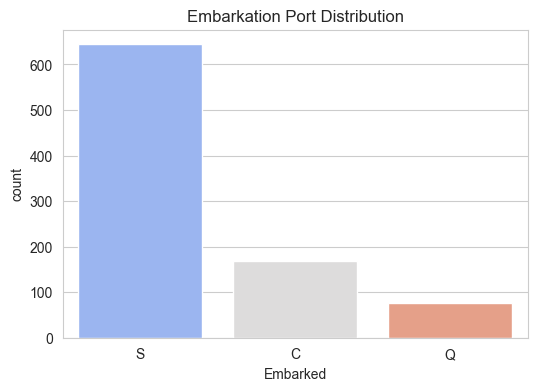

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Embarked', palette='coolwarm')

plt.title("Embarkation Port Distribution")

plt.show()

#### Categorical Feature Insights

- Male passengers were more common than female passengers.
- Most passengers belonged to the third passenger class.
- The majority of passengers embarked from Southampton ('S').
- Passenger class distribution suggests socioeconomic differences among travelers.

#### 2.6 Bivariate Analysis

Bivariate analysis is performed to understand the relationship between individual features and the target variable 'Survived'.

This helps identify which features have the strongest influence on passenger survival.

#### Survival by Gender

In [22]:
#Survival Rate by Gender
gender_survival = train.groupby('Sex')['Survived'].mean() * 100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

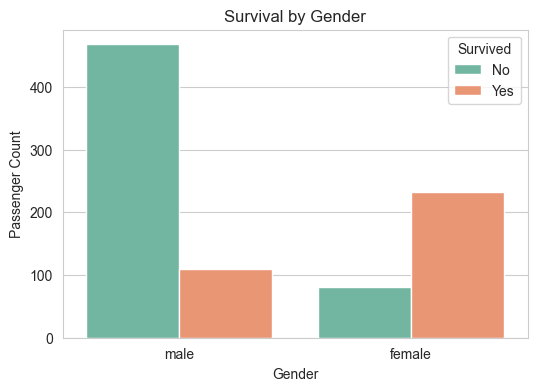

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='Sex', hue='Survived', palette='Set2')

plt.title("Survival by Gender")

plt.xlabel("Gender")
plt.ylabel("Passenger Count")

plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

#### Gender vs Survival Insights

- Female passengers had a significantly higher survival rate compared to male passengers.
- This suggests that gender played a major role during rescue operations.
- The results support the historical “women and children first” evacuation policy.

#### Survival by Passenger Class

In [24]:
#Survival Rate by Class
class_survival = train.groupby('Pclass')['Survived'].mean() * 100
class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

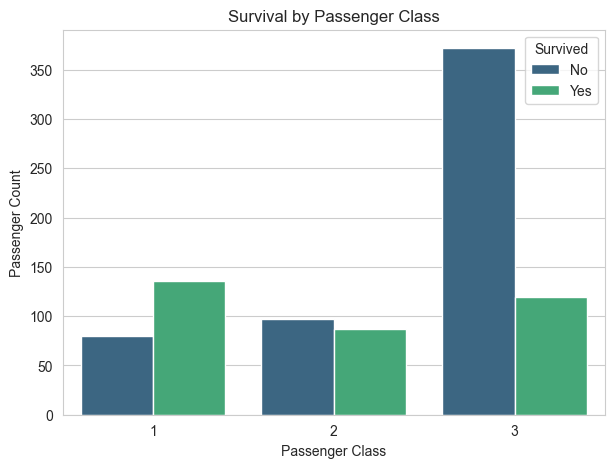

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(data=train, x='Pclass', hue='Survived', palette='viridis')

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

#### Passenger Class vs Survival Insights

- First-class passengers had the highest survival rate.
- Third-class passengers experienced the lowest survival rate.
- This indicates that socioeconomic status may have influenced access to rescue opportunities.

#### Survival by Embarkation Port

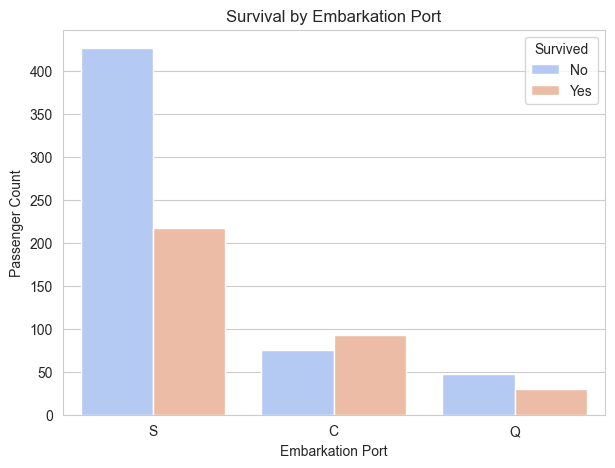

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(data=train, x='Embarked', hue='Survived', palette='coolwarm')

plt.title("Survival by Embarkation Port")

plt.xlabel("Embarkation Port")
plt.ylabel("Passenger Count")

plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

#### Embarkation Port vs Survival Insights

- Passengers embarking from Cherbourg (C) appear to have a higher survival rate.
- Southampton (S) had the highest number of passengers overall.
- Survival patterns may be associated with passenger class and fare distribution across embarkation points.

#### Survival by Age

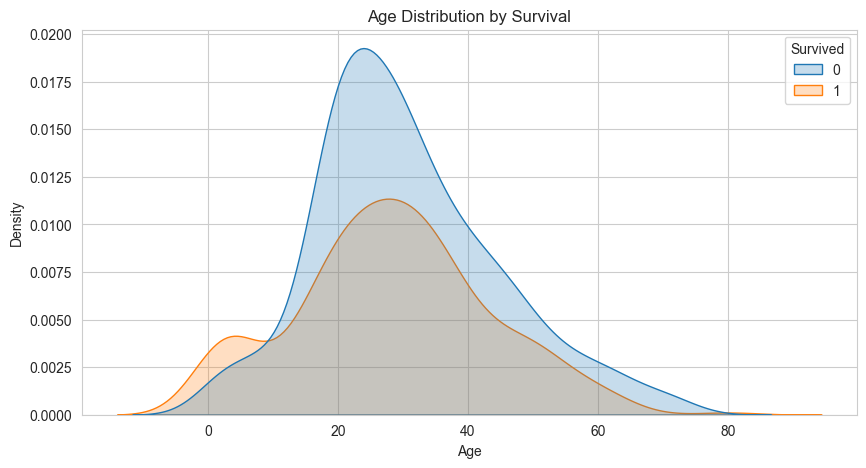

In [27]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=train,
    x='Age',
    hue='Survived',
    fill=True
)

plt.title("Age Distribution by Survival")

plt.xlabel("Age")

plt.show()

#### Age vs Survival Insights

- Younger passengers, particularly children, showed relatively higher survival rates.
- Adult passengers represented the majority of non-survivors.
- Age appears to have influenced rescue priority during the disaster.

#### Survival by Fare

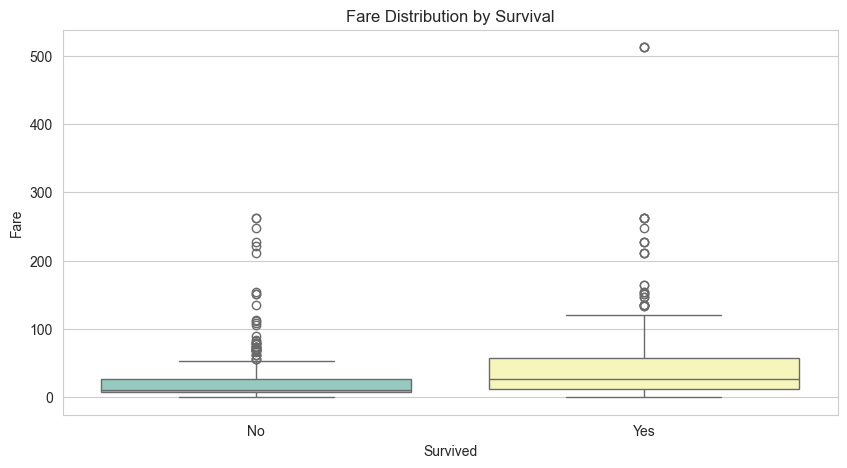

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(data=train, x='Survived', y='Fare', palette='Set3')

plt.title("Fare Distribution by Survival")

plt.xlabel("Survived")
plt.ylabel("Fare")

plt.xticks([0,1], ['No', 'Yes'])

plt.show()

#### Fare vs Survival Insights

- Passengers who paid higher fares generally had better survival rates.
- Higher fare values are strongly associated with first-class passengers.
- Fare may indirectly reflect passenger class and socioeconomic status.

#### Family-Based Analysis

In [29]:
# Create FamilySize Feature for EDA
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


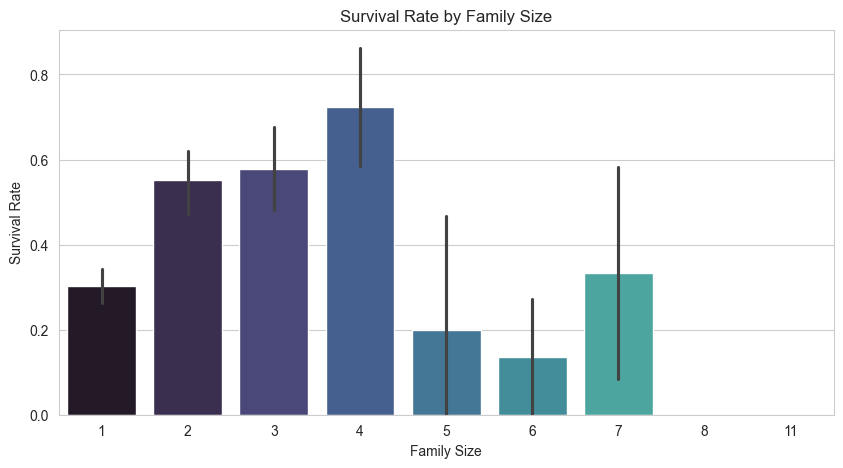

In [30]:
# Survival by Family Size
plt.figure(figsize=(10,5))

sns.barplot(data=train, x='FamilySize', y='Survived', palette='mako')

plt.title("Survival Rate by Family Size")

plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

#### Family Size vs Survival Insights

- Passengers travelling in small families showed higher survival rates.
- Very large family groups experienced lower survival rates.
- Passengers travelling completely alone also showed lower survival probability compared to moderate-sized family groups.

#### Survival Correlation Heatmap

In [31]:
# Temporary encoding for correlation analysis
train_corr = train.copy()
train_corr['Sex'] = train_corr['Sex'].map({'male': 0, 'female': 1})
train_corr['Embarked'] = train_corr['Embarked'].map({'S': 0, 'C': 1,'Q': 2 })

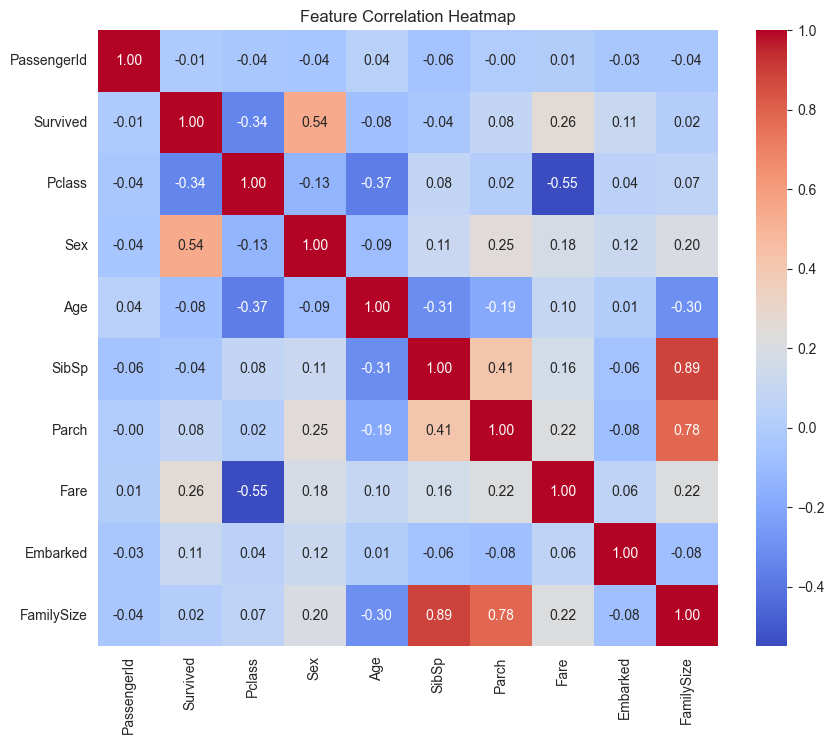

In [32]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
corr_matrix = train_corr.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

### 2.7 Multivariate Analysis
- Multivariate analysis helps understand how multiple variables interact together and influence passenger survival outcomes.
- This analysis provides deeper insights beyond individual feature relationships.

#### Survival by Gender and Passenger Class

<Figure size 800x500 with 0 Axes>

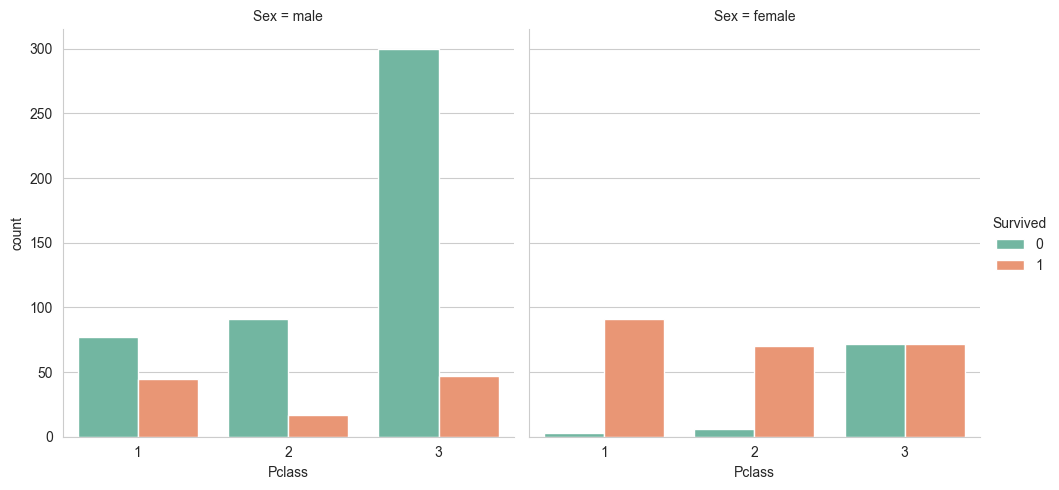

In [33]:
plt.figure(figsize=(8,5))
sns.catplot( data=train, x='Pclass', hue='Survived', col='Sex', kind='count', palette='Set2')
plt.show()

#### Gender and Passenger Class Insights

- Female passengers had higher survival rates across all passenger classes.
- First-class female passengers showed the highest survival probability.
- Third-class male passengers experienced the lowest survival rates.
- Both gender and socioeconomic status strongly influenced survival outcomes.

#### Age Distribution by Passenger Class and Survival

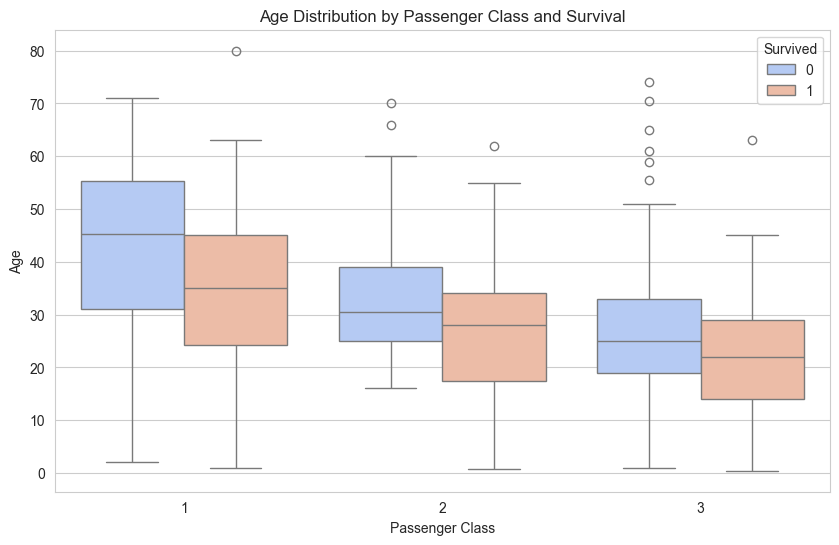

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot( data=train, x='Pclass', y='Age', hue='Survived', palette='coolwarm')
plt.title("Age Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

#### Age, Passenger Class, and Survival Insights

- Younger passengers generally showed better survival outcomes.
- First-class passengers across multiple age groups had improved survival chances.
- Third-class passengers showed lower survival rates regardless of age category.

#### Fare Distribution by Class and Survival

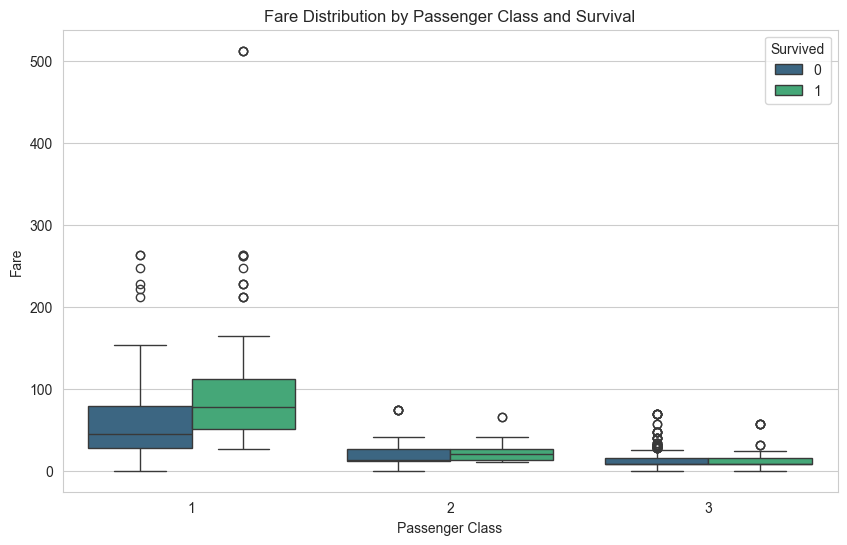

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train, x='Pclass', y='Fare', hue='Survived', palette='viridis')
plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

#### Fare, Passenger Class, and Survival Insights

- Higher fares are concentrated within first-class passengers.
- Survivors generally paid higher fares compared to non-survivors.
- Fare and passenger class together show strong influence on survival probability.

#### Survival by Embarkation and Class

<Figure size 1000x500 with 0 Axes>

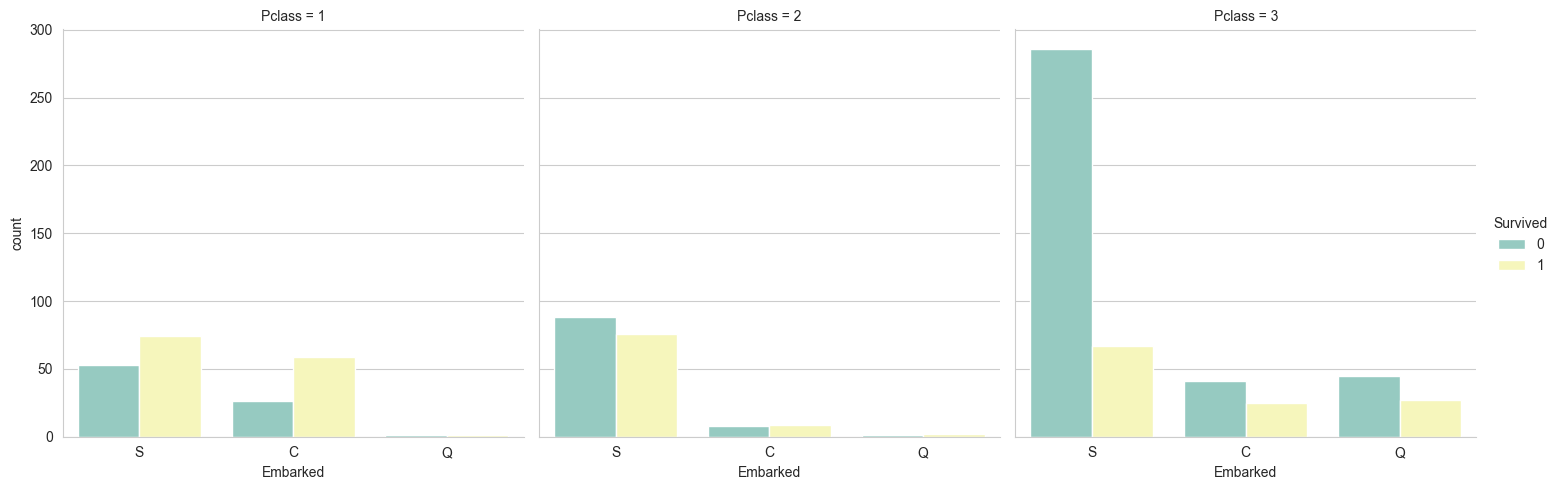

In [36]:
plt.figure(figsize=(10,5))
sns.catplot(data=train, x='Embarked', hue='Survived', col='Pclass', kind='count', palette='Set3')
plt.show()

#### Embarkation Point and Passenger Class Insights

- Survival patterns differ across embarkation points and passenger classes.
- Passengers embarking from Cherbourg (C) appear to have better survival rates, especially among higher passenger classes.
- Southampton (S) had the largest concentration of third-class passengers.

#### Pairplot

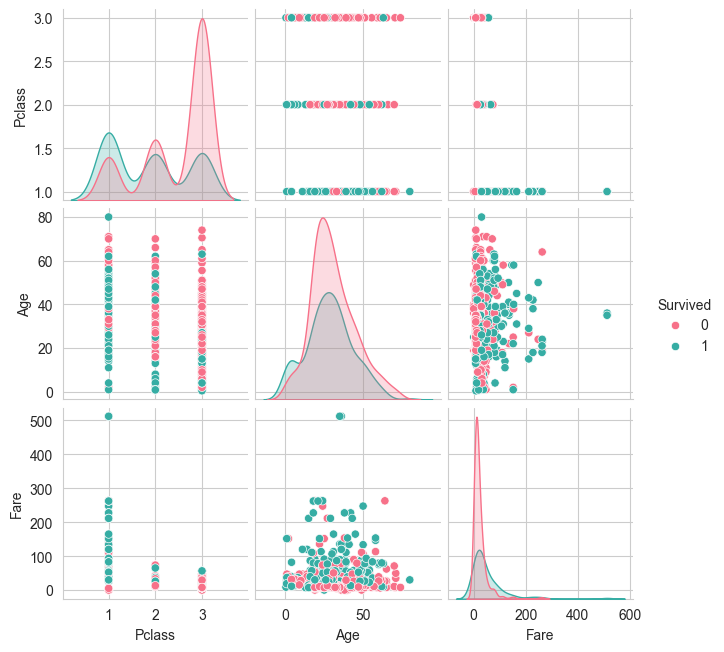

In [37]:
# Pairplot
selected_features = ['Survived', 'Pclass', 'Age', 'Fare']
sns.pairplot(train[selected_features].dropna(), hue='Survived', palette='husl', height=2.2)
plt.show()

#### Pairplot Insights

- Passenger class and fare show visible separation between survivors and non-survivors.
- The visualization highlights potential nonlinear relationships among features.

### 2.8 EDA Summary Findings
The exploratory data analysis revealed several important patterns related to passenger survival:

- Key Findings:

1. Female passengers had significantly higher survival rates compared to male passengers.

2. First-class passengers showed much higher survival probability than third-class passengers.

3. Younger passengers, particularly children, appeared to receive higher rescue priority.

4. Passengers paying higher fares generally experienced better survival outcomes.

5. Small family groups had better survival rates compared to passengers travelling alone or in very large families.

6. Passenger class, gender, fare, and age are likely to be strong predictive features for machine learning models.

7. Missing values in Age, Cabin and Embarked will require preprocessing before model training.


- EDA Conclusion:

The analysis confirms that multiple demographic and socioeconomic factors influenced survival outcomes during the Titanic disaster. These insights will guide the feature engineering and modeling stages of the machine learning pipeline.

## Phase 3 – Data Cleaning & Preprocessing

In this phase, missing values are handled, useful features are engineered, categorical variables are encoded and datasets are prepared for machine learning models.

To ensure consistency during preprocessing and feature engineering, the training and testing datasets are temporarily combined.

### 3.1 Combine train & test data

The datasets are combined temporarily to ensure that preprocessing steps such as missing value handling, feature engineering, encoding and scaling are applied consistently across both datasets. This helps prevent feature mismatch issues during model prediction.

In [38]:
# Remove EDA-created columns before combining, if they already exist
train_clean = train.drop(columns=['FamilySize'], errors='ignore')
test_clean = test.drop(columns=['FamilySize'], errors='ignore')

# Save PassengerId
test_passenger_ids = test_clean['PassengerId']

# Add placeholder target column to test dataset
test['Survived'] = np.nan

# Combine train and test
combined = pd.concat([train_clean, test_clean], ignore_index=True)

print("Combined shape:", combined.shape)

Combined shape: (1309, 12)


In [39]:
combined.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.2 Missing Value Analysis

In [40]:
# Missing values in combined dataset
combined.isnull().sum().sort_values(ascending=False)

Cabin          1014
Survived        418
Age             263
Embarked          2
Fare              1
Name              0
PassengerId       0
Pclass            0
Parch             0
SibSp             0
Sex               0
Ticket            0
dtype: int64

### 3.3 Handling Missing Values

#### Age Imputation

- Age Imputation Strategy: Missing age values were imputed using the median age grouped by passenger gender and passenger class.
- This approach preserves demographic patterns within the dataset and provides more realistic estimates compared to using a single overall median age for all passengers.
- Median imputation was preferred over mean imputation because the age distribution contains outliers and skewness.

In [41]:
# Fill missing Age values using median age grouped by Sex and Pclass
combined['Age'] = combined.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

#### Embarked Imputation

In [42]:
# Fill missing Embarked values using mode
combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)

0       S
1       C
2       S
3       S
4       S
       ..
1304    S
1305    C
1306    S
1307    S
1308    C
Name: Embarked, Length: 1309, dtype: str

#### Fare Imputation

Test dataset contains one missing Fare value.

In [43]:
# Fill missing Fare values using median
combined['Fare'].fillna(combined['Fare'].median(), inplace=True)

0         7.2500
1        71.2833
2         7.9250
3        53.1000
4         8.0500
          ...   
1304      8.0500
1305    108.9000
1306      7.2500
1307      8.0500
1308     22.3583
Name: Fare, Length: 1309, dtype: float64

#### Cabin Handling
Instead of dropping completely, create a new feature.

In [44]:
# Create HasCabin feature
combined['HasCabin'] = combined['Cabin'].notnull().astype(int)

#### Missing Value Treatment Summary

- Missing Age values were imputed using grouped median values based on passenger class and gender.
- Missing Embarked values were filled using the most frequent embarkation port.
- Missing Fare values were filled using the median fare.
- Instead of removing the Cabin column completely, a new binary feature HasCabin was created to capture cabin availability information.

### 3.4 Feature Engineering

#### Family Size

In [45]:
# Create FamilySize feature
combined['FamilySize'] = (combined['SibSp'] + combined['Parch'] + 1)

# Create IsAlone feature
combined['IsAlone'] = np.where(combined['FamilySize'] == 1, 1, 0)

# Extract Title from Name
combined['Title'] = combined['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


#### Group Rare Titles

In [46]:
# View unique titles
combined['Title'].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [47]:
# Group & replace rare titles
combined['Title'] = combined['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
combined['Title'] = combined['Title'].replace(['Mlle', 'Ms'], 'Miss')
combined['Title'] = combined['Title'].replace('Mme','Mrs')

In [48]:
combined['Title'].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

#### Age Bands

In [49]:
# Create AgeGroup feature
combined['AgeGroup'] = pd.cut(combined['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
combined['AgeGroup'].value_counts()

AgeGroup
YoungAdult    755
Adult         328
Teen           99
Child          94
Senior         33
Name: count, dtype: int64

#### Fare Per Person

In [50]:
# Create FarePerPerson feature
combined['FarePerPerson'] = ( combined['Fare'] / combined['FamilySize'])

#### Feature Engineering Summary

Several new features were created to improve model performance:

- FamilySize: captures the total number of family members travelling together.
- IsAlone: identifies passengers travelling alone.
- Title: extracts social titles from passenger names, which may reflect gender, age, or social status.
- AgeGroup: categorizes passengers into meaningful age ranges.
- FarePerPerson: estimates the fare contribution per passenger.
- HasCabin: captures whether cabin information was available.

### 3.5 Drop Unnecessary Columns

In [51]:
# Drop unnecessary columns
df = combined.drop(columns=['PassengerId','Name','Ticket','Cabin'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize,IsAlone,Title,AgeGroup,FarePerPerson
0,0.0,3,male,22.0,1,0,7.2500,S,0,2,0,Mr,YoungAdult,3.62500
1,1.0,1,female,38.0,1,0,71.2833,C,1,2,0,Mrs,Adult,35.64165
2,1.0,3,female,26.0,0,0,7.9250,S,0,1,1,Miss,YoungAdult,7.92500
3,1.0,1,female,35.0,1,0,53.1000,S,1,2,0,Mrs,YoungAdult,26.55000
4,0.0,3,male,35.0,0,0,8.0500,S,0,1,1,Mr,YoungAdult,8.05000


In [52]:
# Check remaining missing values
df.isnull().sum().sort_values(ascending=False)

Survived         418
Embarked           2
Fare               1
FarePerPerson      1
Sex                0
Pclass             0
Parch              0
SibSp              0
Age                0
HasCabin           0
FamilySize         0
IsAlone            0
Title              0
AgeGroup           0
dtype: int64

In [53]:
# Fill missing Embarked values using mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# Fill missing Fare values using median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())


In [54]:
# Recalculate FarePerPerson
df['FarePerPerson'] = ( df['Fare'] / df['FamilySize'])

In [55]:
df.isnull().sum().sort_values(ascending=False)

Survived         418
Pclass             0
Sex                0
Age                0
SibSp              0
Parch              0
Fare               0
Embarked           0
HasCabin           0
FamilySize         0
IsAlone            0
Title              0
AgeGroup           0
FarePerPerson      0
dtype: int64

#### Remaining Missing Value Treatment

- Missing values in Embarked were filled using the mode because it is a categorical feature.
- Missing values in Fare were filled using the median due to skewness and outliers.
- FarePerPerson was recalculated after fare imputation.
- Missing values in 'Survived' belong to the test dataset and were intentionally preserved for final prediction generation.

#### 3.6 Separate Numerical and Categorical Features

- Encoding and Scaling : Machine learning models require numerical input features. Therefore, categorical variables must be encoded and numerical features may require scaling before model training.

In [56]:
# categorical columns
categorical_cols = ['Sex', 'Embarked', 'Title', 'AgeGroup']

# numerical columns
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson']

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Sex', 'Embarked', 'Title', 'AgeGroup']

Numerical Columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson']


#### 3.7 One-Hot Encoding

In [57]:
# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert boolean columns to integers
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,FarePerPerson,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
0,0.0,3,22.0,1,0,7.2500,0,2,0,3.62500,1,0,1,0,1,0,0,0,1,0,0
1,1.0,1,38.0,1,0,71.2833,1,2,0,35.64165,0,0,0,0,0,1,0,0,0,1,0
2,1.0,3,26.0,0,0,7.9250,0,1,1,7.92500,0,0,1,1,0,0,0,0,1,0,0
3,1.0,1,35.0,1,0,53.1000,1,2,0,26.55000,0,0,1,0,0,1,0,0,1,0,0
4,0.0,3,35.0,0,0,8.0500,0,1,1,8.05000,1,0,1,0,1,0,0,0,1,0,0


#### 

Categorical variables were converted into numerical format using One-Hot Encoding.

'drop_first=True' was used to reduce multicollinearity by avoiding redundant dummy variables.

### 3.8 Scale Numerical Features

In [58]:
# Initialize scaler
scaler = StandardScaler()

# Scale numerical features
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,FarePerPerson,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
0,0.0,0.841916,-0.549555,0.481288,-0.445,-0.503291,-0.539377,0.073352,-1.233758,-0.472442,1,0,1,0,1,0,0,0,1,0,0
1,1.0,-1.546098,0.661353,0.481288,-0.445,0.734744,1.853992,0.073352,-1.233758,0.423194,0,0,0,0,0,1,0,0,0,1,0
2,1.0,0.841916,-0.246828,-0.479087,-0.445,-0.490240,-0.539377,-0.558346,0.810532,-0.352154,0,0,1,1,0,0,0,0,1,0,0
3,1.0,-1.546098,0.434307,0.481288,-0.445,0.383183,1.853992,0.073352,-1.233758,0.168863,0,0,1,0,0,1,0,0,1,0,0
4,0.0,0.841916,0.434307,-0.479087,-0.445,-0.487824,-0.539377,-0.558346,0.810532,-0.348657,1,0,1,0,1,0,0,0,1,0,0


#### Feature Scaling

Numerical features were standardized using 'StandardScaler'.

Standardization transforms features to have:
- mean ≈ 0
- standard deviation ≈ 1

This helps improve model convergence and ensures fair feature contribution during training.

### 3.9 Separate Train and Test Again

In [59]:
# Separate rows with known survival values
train_processed = df_encoded[df_encoded['Survived'].notnull()]

# Separate rows without survival values
test_processed = df_encoded[df_encoded['Survived'].isnull()]

print(train_processed.shape)
print(test_processed.shape)

(891, 21)
(418, 21)


### 3.10 Create X and y

In [60]:
# Features
X = train_processed.drop(columns=['Survived'])

# Target
y = train_processed['Survived'].astype(int)

#### Test Dataset

In [61]:
# Final test dataset
X_test_final = test_processed.drop(columns=['Survived'])

#### 3.11 Train-Validation Split

In [62]:
# Split training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (712, 20)
X_valid shape: (179, 20)


#### Train-Test Split

The dataset was split into training and validation sets using an 80-20 ratio.

stratify=y was applied to preserve the original survival class distribution in both datasets.

In [63]:
#Final Dataset Check
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,FarePerPerson,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior
692,0.841916,-0.322510,-0.479087,-0.445000,0.448839,-0.539377,-0.558346,0.810532,1.006569,1,0,1,0,1,0,0,0,1,0,0
481,-0.352091,0.018058,-0.479087,-0.445000,-0.643464,-0.539377,-0.558346,0.810532,-0.573848,1,0,1,0,1,0,0,0,1,0,0
527,-1.546098,0.964080,-0.479087,-0.445000,3.644466,1.853992,-0.558346,0.810532,5.630219,1,0,1,0,1,0,0,0,0,1,0
855,0.841916,-0.852282,-0.479087,0.710763,-0.462689,-0.539377,0.073352,-1.233758,-0.443070,0,0,1,0,0,1,0,1,0,0,0
801,-0.352091,0.131580,0.481288,0.710763,-0.135941,-0.539377,0.705051,-1.233758,-0.329075,0,0,1,0,0,1,0,0,1,0,0


## Phase 4 – Modeling & Evaluation
In this phase, multiple machine learning classification models are trained and evaluated to predict passenger survival.

The objective is to compare model performance using various evaluation metrics and select the best-performing model for final prediction generation.

### 4.1 Define models

In [64]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

### 4.2 Train and evaluate models

In [65]:
# Train and evaluate all models
results = []

for model_name, model in models.items():
    pipeline = Pipeline([("model", model)])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1 Score": f1_score(y_valid, y_pred)
    })

model_results = pd.DataFrame(results).sort_values(
    by="F1 Score",
    ascending=False
)

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826816,0.787879,0.753623,0.770370
1,Decision Tree,0.826816,0.787879,0.753623,0.770370
2,Random Forest,0.798883,0.753846,0.710145,0.731343
3,Gradient Boosting,0.782123,0.758621,0.637681,0.692913


### 4.3 Visualize Model Comparison

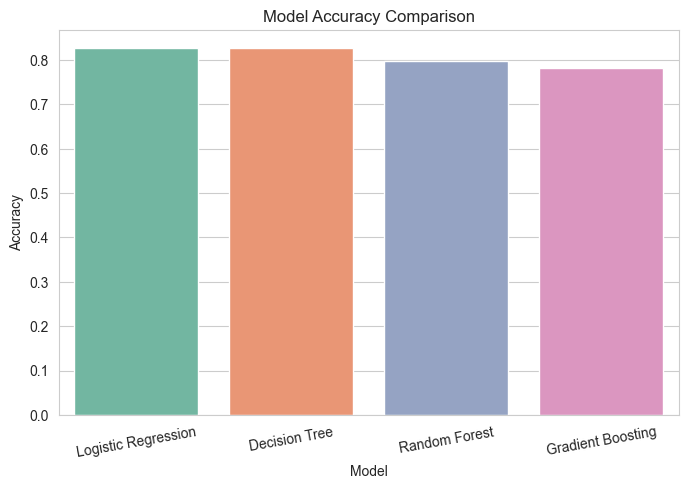

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(data=model_results, x='Model', y='Accuracy', palette='Set2')
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=10)
plt.show()

#### Modeling Approach

Multiple classification algorithms were trained and evaluated using a pipeline-based approach.

This method keeps the modeling workflow clean, reusable and consistent across different algorithms. The models were compared using Accuracy, Precision, Recall and F1-Score.

###  4.4 Model Evaluation Summary

Multiple classification algorithms were trained and evaluated on the validation dataset.

### Key Observations

- Logistic Regression and Decision Tree achieved the highest overall performance.
- Logistic Regression provided strong generalization with balanced precision and recall.
- Random Forest performed reasonably well but did not outperform simpler models in this case.
- Gradient Boosting showed comparatively lower recall and F1-score.

### Final Model Selection

Logistic Regression was selected as the final model because it achieved strong overall performance while maintaining simplicity and interpretability.

### 4.5 Cross Validation

Cross-validation was performed to evaluate model stability and generalization performance across multiple folds.

In [67]:
# Cross-validation for Logistic Regression
cv_scores = cross_val_score(LogisticRegression(max_iter=1000),X,y,cv=5,scoring='accuracy')

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.82681564 0.82022472 0.80898876 0.82022472 0.84269663]

Mean CV Accuracy: 0.8237900947837549


### Cross Validation Results

The Logistic Regression model achieved consistent performance across all cross-validation folds.

#### Key Observations

- The average cross-validation accuracy was approximately 82.4%.
- Validation scores remained stable across folds with low variation.
- This indicates that the model generalizes well to unseen data.
- The results suggest that the model is not significantly overfitting the training dataset.

Overall, Logistic Regression demonstrated strong and reliable predictive performance for the Titanic survival classification problem.

### 4.6 ROC Curve Analysis

The Receiver Operating Characteristic (ROC) Curve evaluates the model’s ability to distinguish between survival classes across different classification thresholds.

The Area Under the Curve (AUC) measures overall classification performance:
- AUC closer to 1 indicates better model performance.
- AUC closer to 0.5 indicates poor classification ability.

In [68]:
# Train Logistic Regression model again for ROC analysis

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
# Probability predictions
y_prob_log = log_reg.predict_proba(X_valid)[:, 1]

In [70]:
# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_valid, y_prob_log)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8684


#### Plot ROC Curve

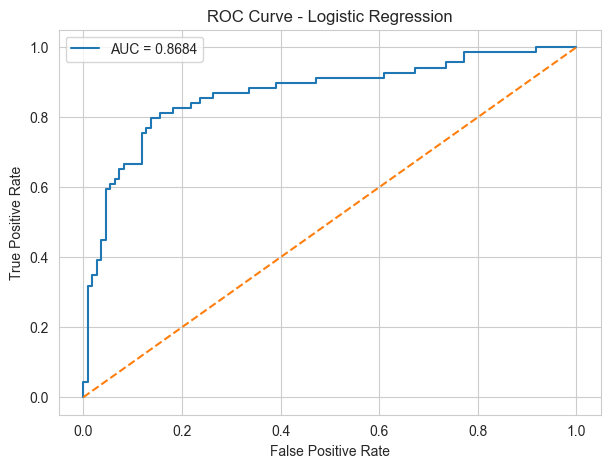

In [71]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, y_prob_log)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

### ROC-AUC Interpretation

The Logistic Regression model achieved a ROC-AUC score of approximately 0.87, indicating strong classification performance.

The ROC curve demonstrates that the model effectively distinguishes between survivors and non-survivors across different classification thresholds.

An AUC score above 0.80 generally reflects a strong predictive model, confirming that the selected features and preprocessing steps contributed positively to model performance.

## Phase 5 – Final Prediction & Submission CSV

The best-performing model is trained on the full processed training dataset and then used to generate predictions for the test dataset.

### 5.1 Train Final Model

In [72]:
# Final selected model
final_model = LogisticRegression(max_iter=1000)

# Train on full processed training data
final_model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [73]:
# Generate final predictions
final_predictions = final_model.predict(X_test_final)

final_predictions[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [74]:
# Create submission dataframe
submission = pd.DataFrame({'PassengerId': test_passenger_ids, 'Survived': final_predictions.astype(int)})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [75]:
# Save final submission file
submission.to_csv("../outputs/titanic_submission.csv", index=False)
print("Submission file saved successfully.")

Submission file saved successfully.


In [76]:
submission.shape

(418, 2)

### Final Prediction Summary

Logistic Regression was selected as the final model because it achieved strong validation performance, stable cross-validation results and a high ROC-AUC score.

The final model was trained using the complete processed training dataset and then applied to the test dataset to generate survival predictions.

The final submission file contains two columns:

- PassengerId
- Survived

# Project Conclusion

This project successfully developed a machine learning classification model to predict Titanic passenger survival using historical passenger data.

The project followed a complete end-to-end machine learning workflow including:

- Business understanding
- Exploratory Data Analysis (EDA)
- Missing value treatment
- Feature engineering
- Data preprocessing
- Model training and evaluation
- Cross-validation
- ROC-AUC analysis
- Final prediction generation

## Key Findings

- Gender, passenger class, fare and age were among the most influential factors affecting survival.
- Female passengers and first-class passengers showed significantly higher survival rates.
- Feature engineering improved model understanding by introducing variables such as FamilySize, IsAlone, Title and FarePerPerson.

## Final Model Performance

Logistic Regression achieved the strongest balance between accuracy, interpretability and generalization performance.

### Final Evaluation Highlights

- Validation Accuracy: approximately 82%
- Cross-Validation Accuracy: approximately 82%
- ROC-AUC Score: approximately 0.87

These results indicate strong classification capability and stable model generalization.

## Conclusion

The project demonstrates how machine learning can be applied to historical datasets to identify patterns and generate predictive insights.

The workflow followed in this project reflects industry-standard practices for supervised machine learning classification problems.

In [77]:
# Final dataset shapes

print("Training Features Shape :", X.shape)
print("Training Target Shape   :", y.shape)
print("Final Test Shape        :", X_test_final.shape)
print("Submission Shape        :", submission.shape)

Training Features Shape : (891, 20)
Training Target Shape   : (891,)
Final Test Shape        : (418, 20)
Submission Shape        : (418, 2)
